# Ridge Regression

**Course:** 23CSE301 Machine Learning — Capstone Project
**Review:** Review 1
**Track:** Regression
**Dataset:** `diamonds_sampled.csv`
**Primary algorithm:** **Ridge Regression**


In [1]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import joblib

RANDOM_STATE = 42
TEST_SIZE = 0.20
plt.rcParams["figure.figsize"] = (8, 5)


In [2]:
# Resolve paths so the notebook works both inside the GitHub repository and from the uploaded /mnt/data files.
def resolve_file(filename):
    candidates = [
        Path("../data") / filename,
        Path("data") / filename,
        Path(filename),
        Path("/mnt/data") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find {filename}. Checked: {', '.join(str(p) for p in candidates)}"
    )

DATA_PATH = resolve_file("diamonds_sampled.csv")
TARGET = "price"

print("Using dataset:", DATA_PATH.resolve())


Using dataset: C:\Sem-5\ml\jyp_notebook\Reg_review1\diamonds_sampled.csv


In [3]:
class IQRClipper(BaseEstimator, TransformerMixin):
    """Clip numeric values to train-set IQR bounds; fit only on training data."""
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        q1 = np.nanpercentile(X, 25, axis=0)
        q3 = np.nanpercentile(X, 75, axis=0)
        iqr = q3 - q1
        self.lower_ = q1 - self.factor * iqr
        self.upper_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array([], dtype=object)
        return np.asarray(input_features, dtype=object)


## 1. Dataset loading & audit — A1

In [4]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nMissing values per column:")
display(df.isnull().sum().to_frame("missing"))
print("\nDuplicate rows:", int(df.duplicated().sum()))
print("\nTarget summary:")
display(df[TARGET].describe().to_frame("price"))
display(df.head())

print("\nCategorical feature values:")
for c in df.select_dtypes(include="object").columns:
    print(f"{c}: {df[c].nunique()} unique -> {df[c].unique().tolist()}")


Shape: (2100, 11)

Data types:


,dtype
id: 0,int64
carat,float64
cut,str
color,str
clarity,str
depth,float64
table,float64
price,int64
x,float64
y,float64



Missing values per column:


,missing
id: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0



Duplicate rows: 0

Target summary:


,price
count,2100.000000
mean,3971.387143
std,4124.225067
min,360.000000
25%,926.750000
50%,2324.500000
75%,5357.250000
max,18803.000000


,id: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1389,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
1,50053,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
2,41646,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
3,42378,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
4,17245,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61



Categorical feature values:
cut: 5 unique -> ['Ideal', 'Very Good', 'Premium', 'Fair', 'Good']
color: 7 unique -> ['G', 'F', 'E', 'D', 'H', 'I', 'J']
clarity: 8 unique -> ['VVS1', 'VVS2', 'SI2', 'VS1', 'VS2', 'SI1', 'IF', 'I1']


### A1 observation (validate and rewrite in your own words)

The uploaded diamonds dataset contains **2,100 rows and 11 columns**. It includes numerical measurements and the categorical quality features `cut`, `color`, and `clarity`. The target variable is `price`. The audit shows **no missing values and no duplicate rows** in the supplied sample. The `id: 0` column is an identifier and is not treated as a predictive feature.

## 2. Data cleaning — B1

In [5]:
df_clean = df.copy()

# Remove identifier: it labels the record rather than describing diamond characteristics.
df_clean = df_clean.drop(columns=["id: 0"])

print("Duplicates before cleaning:", int(df_clean.duplicated().sum()))
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Duplicates after cleaning:", int(df_clean.duplicated().sum()))

numeric_for_outliers = df_clean.select_dtypes(include=np.number).columns.tolist()
numeric_for_outliers.remove(TARGET)

outlier_rows = []
for col in numeric_for_outliers:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((df_clean[col] < lower) | (df_clean[col] > upper)).sum())
    outlier_rows.append({"Feature": col, "IQR outliers": count, "Lower": lower, "Upper": upper})

outlier_report = pd.DataFrame(outlier_rows).sort_values("IQR outliers", ascending=False)
display(outlier_report)

print("\nInvalid/zero dimension checks:")
for c in ["x", "y", "z"]:
    print(f"{c} <= 0:", int((df_clean[c] <= 0).sum()))

print("\nMissing after cleaning:")
display(df_clean.isnull().sum().to_frame("missing"))


Duplicates before cleaning: 1
Duplicates after cleaning: 0


,Feature,IQR outliers,Lower,Upper
1,depth,114,59.0000,64.6000
0,carat,64,-0.5850,2.0150
2,table,26,51.5000,63.5000
3,x,1,1.8525,9.3925
4,y,1,1.8650,9.3850
5,z,1,1.1650,5.7650



Invalid/zero dimension checks:
x <= 0: 0
y <= 0: 0
z <= 0: 0

Missing after cleaning:


,missing
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


### B1 justification

No missing values or duplicates are present in the supplied file, so no rows are removed for those reasons. IQR screening identifies extreme observations, but extreme diamond measurements can represent legitimate stones rather than errors. Therefore, the notebook **does not delete legitimate observations globally**; instead, numerical IQR clipping is performed **inside the training pipeline**, where its bounds are learned from the training data only. This treats extreme values while avoiding test-set leakage. The identifier column is removed because it is not a physical diamond attribute.

## 3. Feature engineering — B3

In [6]:
df_clean["volume"] = df_clean["x"] * df_clean["y"] * df_clean["z"]

print("New engineered feature: volume = x × y × z")
display(df_clean[["x", "y", "z", "volume", TARGET]].head())


New engineered feature: volume = x × y × z


,x,y,z,volume,price
0,3.97,4.00,2.47,39.223600,559
1,5.44,5.42,3.26,96.120448,2201
2,4.76,4.74,2.95,66.559080,1238
3,4.92,4.89,2.98,71.695224,1304
4,7.44,7.37,4.61,252.779208,6901


### B3 justification

`volume` combines the three spatial dimensions (`x`, `y`, `z`) into one approximate size measure. This can give the regression model a direct representation of physical size that may help explain variation in diamond price beyond considering each dimension separately.

## 4. Exploratory Data Analysis — A2 & A3

### 4.1 Feature distributions

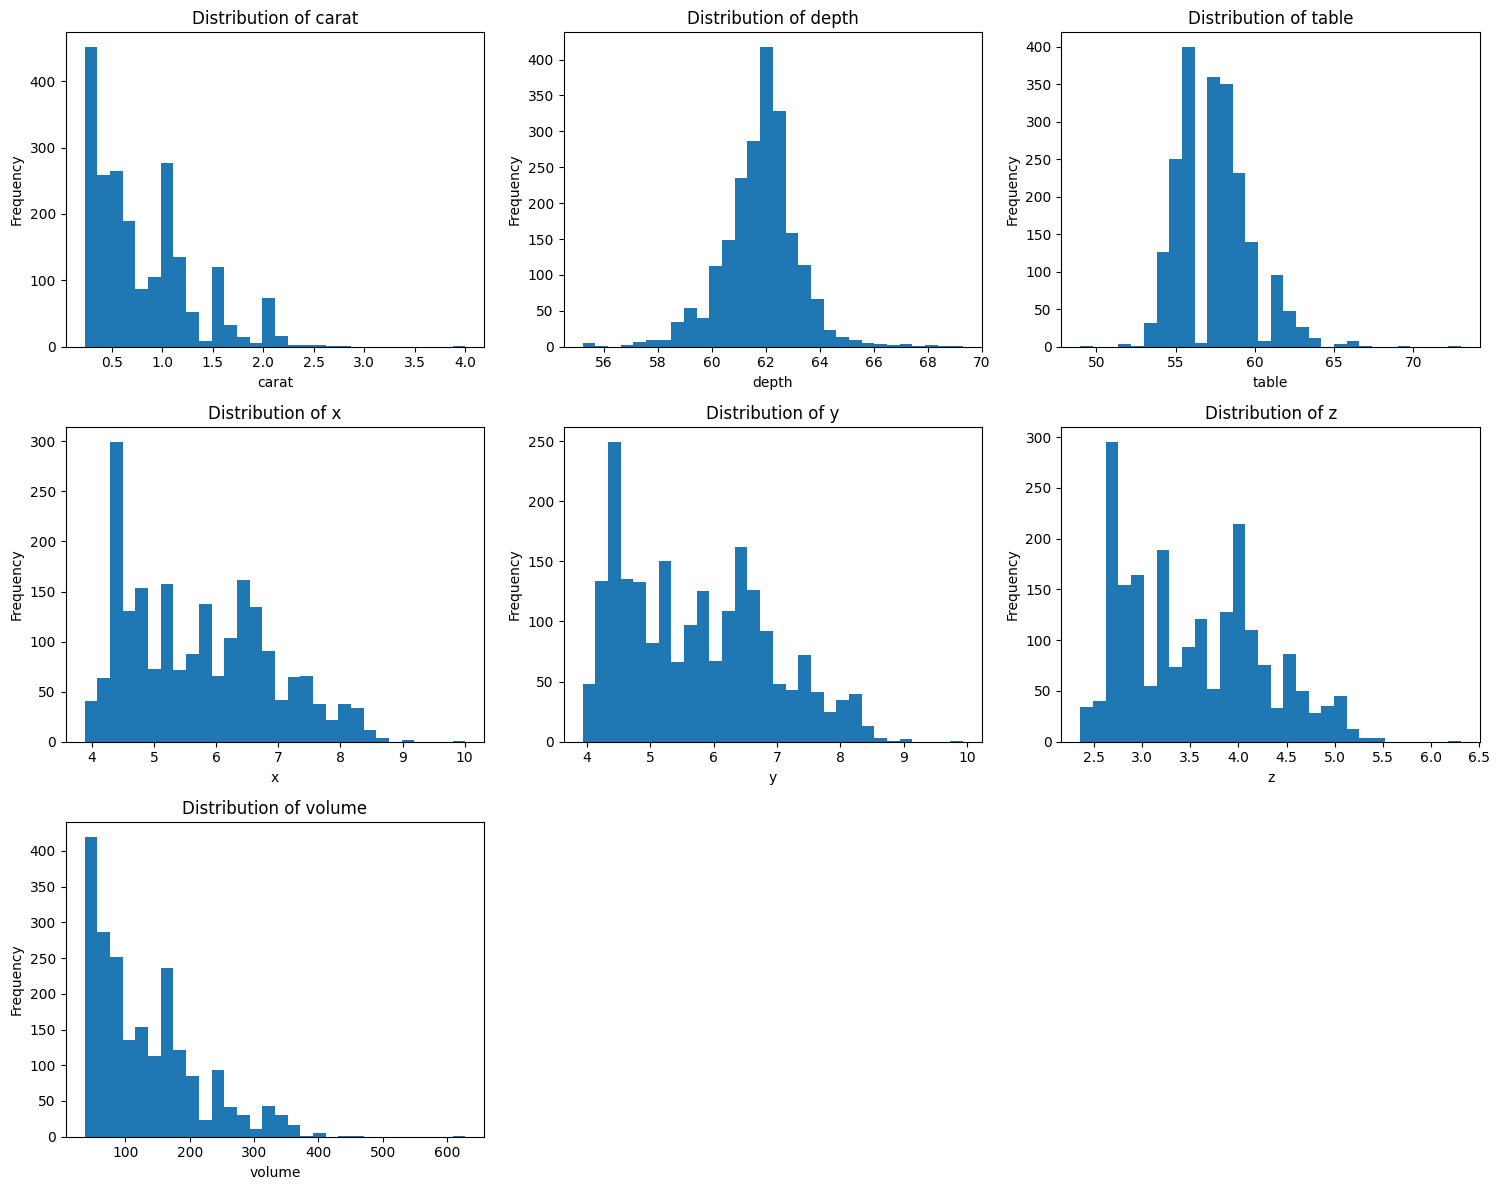

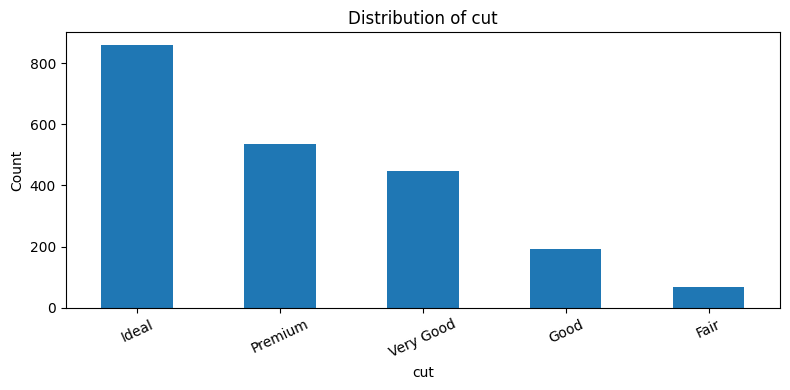

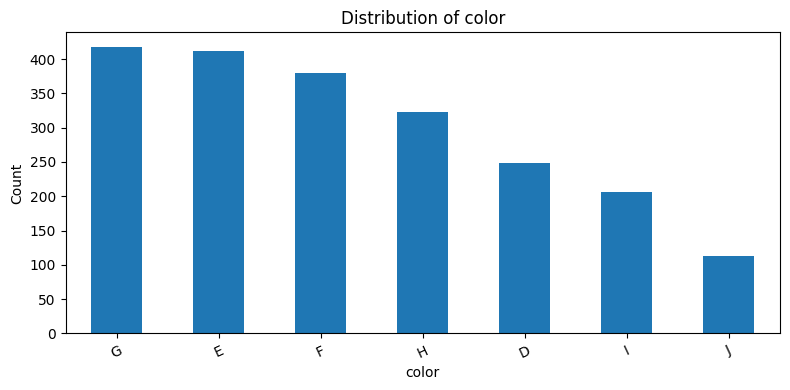

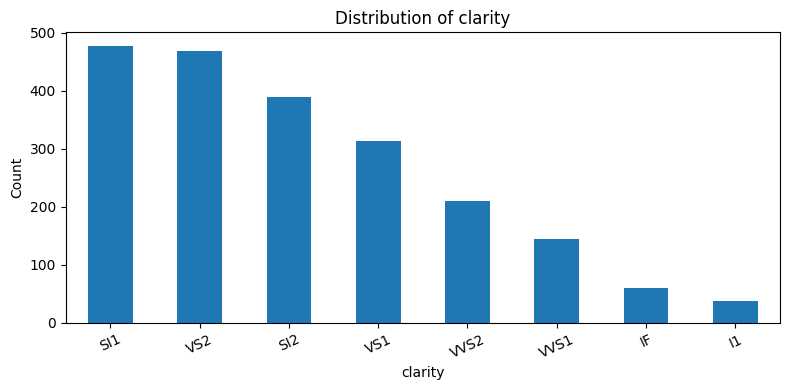

,skewness
carat,1.137481
volume,1.135222
table,0.801652
y,0.441839
x,0.440132
z,0.426798
depth,-0.105170


In [7]:
numeric_features = [c for c in df_clean.select_dtypes(include=np.number).columns if c != TARGET]
categorical_features = df_clean.select_dtypes(include="object").columns.tolist()

ncols = 3
nrows = int(np.ceil(len(numeric_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.asarray(axes).reshape(-1)
for i, col in enumerate(numeric_features):
    axes[i].hist(df_clean[col].dropna(), bins=30)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

for col in categorical_features:
    plt.figure(figsize=(8, 4))
    df_clean[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

skew = df_clean[numeric_features].skew().sort_values(ascending=False)
display(skew.to_frame("skewness"))


### A2/A3 observation (validate and rewrite)

The numerical distributions are not all symmetric; several variables show visible skew/tails, while the categorical plots show uneven frequencies across quality categories. These patterns motivate robust preprocessing and make it useful to compare both linear and nonlinear regression models.

### 4.2 Correlation heatmap

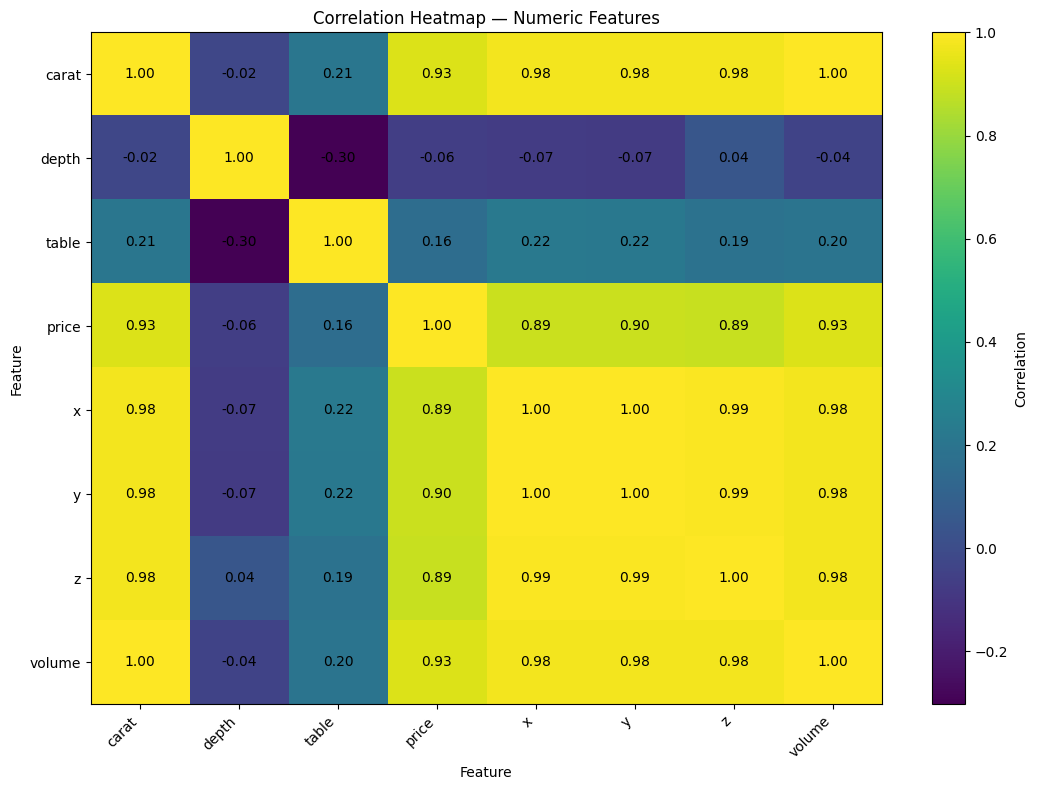

,corr_with_price
volume,0.931300
carat,0.929040
y,0.896134
x,0.893700
z,0.888481
table,0.161579
depth,-0.063104


In [8]:
plt.figure(figsize=(11, 8))
corr = df_clean.select_dtypes(include=np.number).corr()
plt.imshow(corr.values, interpolation="nearest", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.title("Correlation Heatmap — Numeric Features")
plt.xlabel("Feature")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

price_corr = corr[TARGET].drop(TARGET).sort_values(ascending=False)
display(price_corr.to_frame("corr_with_price"))


### A3 observation

In the supplied data, `carat` has the strongest positive correlation with `price`, followed by the physical dimensions `y`, `x`, and `z`. This suggests that overall diamond size is strongly associated with price. Correlated predictors also indicate that multicollinearity may matter for linear models.

### 4.3 Target distribution

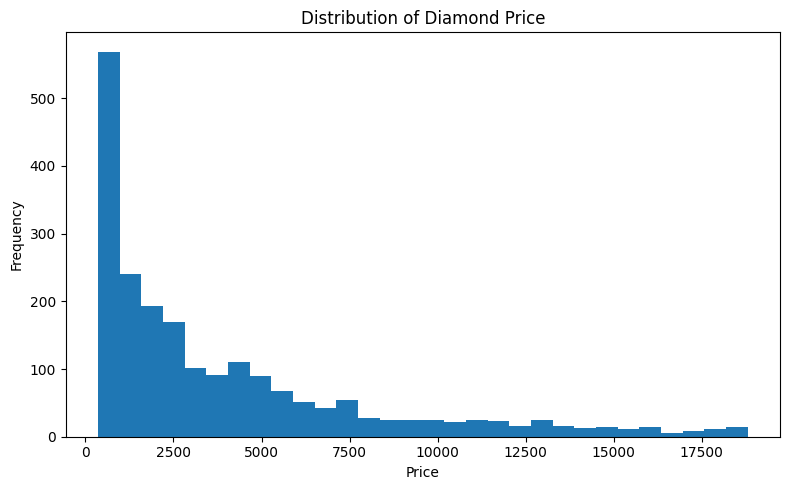

Mean price: 3969.03
Median price: 2322.0
Skewness: 1.612


In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean[TARGET].dropna(), bins=30)
plt.title("Distribution of Diamond Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Mean price:", round(df_clean[TARGET].mean(), 2))
print("Median price:", round(df_clean[TARGET].median(), 2))
print("Skewness:", round(df_clean[TARGET].skew(), 3))


### A3 observation

The target distribution is strongly right-skewed: the mean price is above the median and a relatively small number of diamonds occur at much higher prices. The regression models therefore need to handle a wide target range.

### 4.4 Feature-target relationships — at least two required

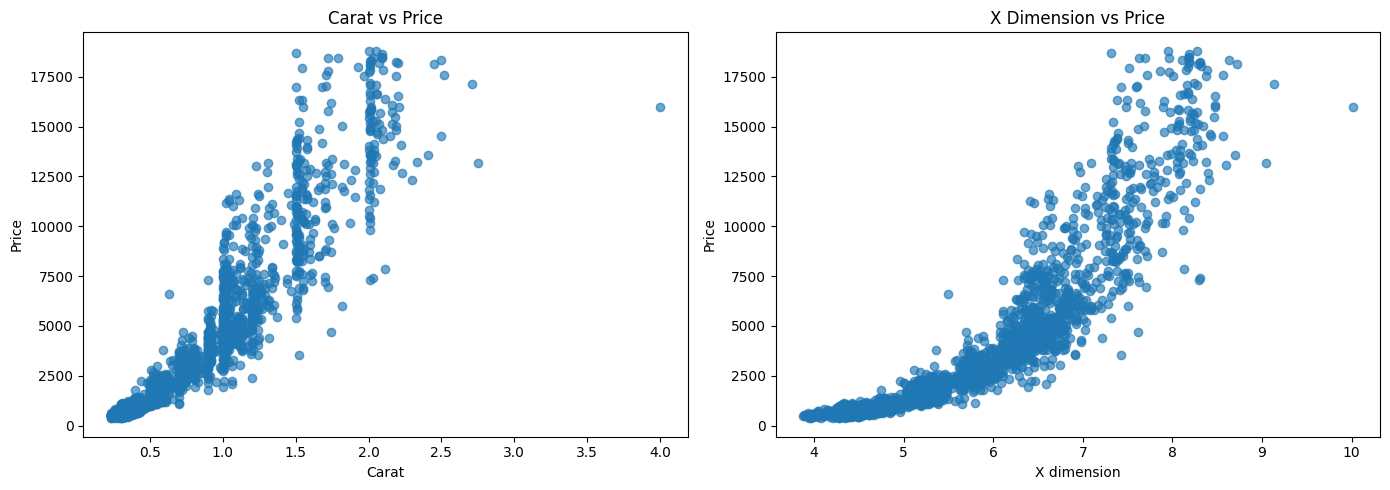

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_clean["carat"], df_clean[TARGET], alpha=0.65)
axes[0].set_title("Carat vs Price")
axes[0].set_xlabel("Carat")
axes[0].set_ylabel("Price")

axes[1].scatter(df_clean["x"], df_clean[TARGET], alpha=0.65)
axes[1].set_title("X Dimension vs Price")
axes[1].set_xlabel("X dimension")
axes[1].set_ylabel("Price")

plt.tight_layout()
plt.show()


### A3 observation

Both scatter plots show clear positive relationships with price, especially for `carat`. The relationships are not perfectly uniform across the full range, which supports comparing a linear baseline with regularized models and, later, nonlinear methods.

## 5. Train/test split & leakage-safe preprocessing — B2

In [11]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("iqr_clip", IQRClipper(factor=1.5)),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Train shape: (1679, 10)
Test shape: (420, 10)
Numeric features: ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume']
Categorical features: ['cut', 'color', 'clarity']


### B2 note

The split is fixed at **80:20 with `random_state=42`** so every regression notebook evaluates on the same held-out examples. Regression targets are continuous, so stratification is not applicable. All imputers, IQR bounds, scalers, and encoders are fitted inside the pipeline on training data only; the untouched test set is transformed using those fitted objects.

## 6. Model training — Ridge Regression

In [12]:
model = Ridge(alpha=1.0)
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model),
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


In [13]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

metrics_df = pd.DataFrame([{
    "Model": pipeline.named_steps["model"].__class__.__name__,
    "R2": r2,
    "RMSE": rmse,
    "MAE": mae,
}])

display(metrics_df)


,Model,R2,RMSE,MAE
0,Ridge,0.935094,1058.787313,676.809865


## 7. 5-fold cross-validated R²

In [14]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="r2", n_jobs=-1)

print("5-fold CV R² scores:", np.round(cv_scores, 4))
print("Mean CV R²:", round(cv_scores.mean(), 4))
print("Std CV R²:", round(cv_scores.std(), 4))


5-fold CV R² scores: [0.9351 0.9366 0.9307 0.9343 0.9435]
Mean CV R²: 0.936
Std CV R²: 0.0042


### CV observation 

Ridge achieved R² = 0.9351, RMSE = 1058.79, and MAE = 676.81. Its mean 5-fold CV R² is about 0.9360 with a standard deviation of 0.0042. Performance is almost unchanged from Linear Regression, suggesting the regularisation strength used here does not materially alter predictive performance on this dataset.

## 8. Ridge Regression — required alpha tuning

In [15]:
ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

ridge_search = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]),
    ridge_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True,
)

ridge_search.fit(X_train, y_train)

tuned_pred = ridge_search.predict(X_test)
tuned_r2 = r2_score(y_test, tuned_pred)

after = pd.DataFrame([{
    "Model": "Ridge Regression (tuned)",
    "Best alpha": ridge_search.best_params_["model__alpha"],
    "Best CV R2": ridge_search.best_score_,
    "Test R2": tuned_r2,
    "RMSE": np.sqrt(mean_squared_error(y_test, tuned_pred)),
    "MAE": mean_absolute_error(y_test, tuned_pred),
}])
display(after)

print("R2 improvement over baseline:", round(tuned_r2 - r2, 6))


,Model,Best alpha,Best CV R2,Test R2,RMSE,MAE
0,Ridge Regression (tuned),1,0.936402,0.935094,1058.787313,676.809865


R2 improvement over baseline: 0.0


### Tuning observation 

The selected Ridge alpha is 1 in the current notebook, with essentially no change in test R² relative to the baseline. This indicates that, within the searched range, stronger coefficient shrinkage did not provide a meaningful predictive advantage.

## 9. Diagnostic visualisations

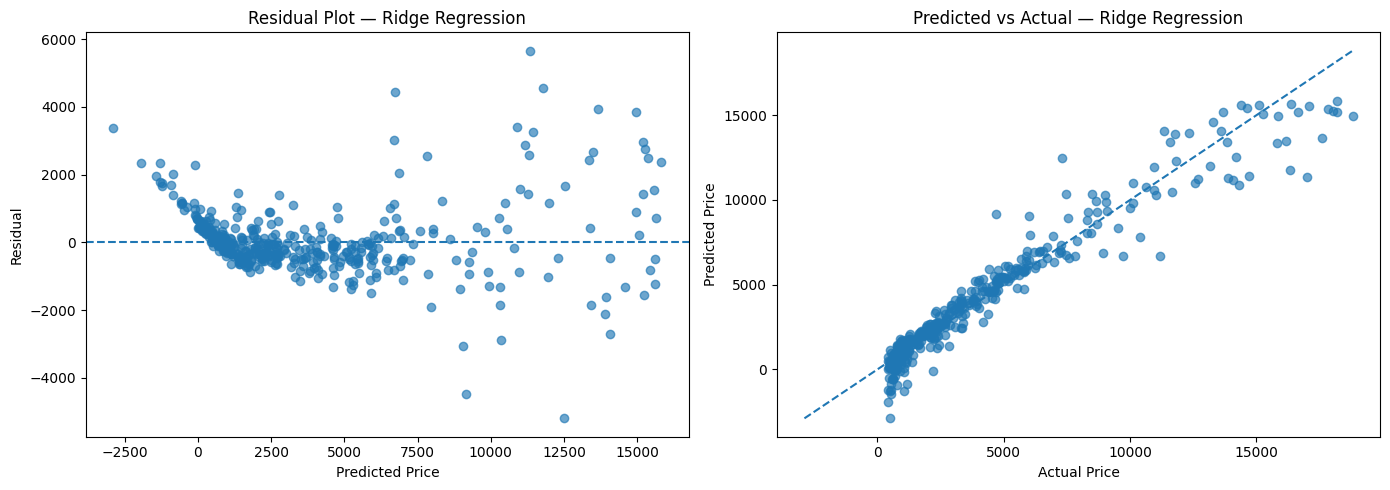

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test - y_pred
axes[0].scatter(y_pred, residuals, alpha=0.65)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residual Plot — Ridge Regression")
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Residual")

axes[1].scatter(y_test, y_pred, alpha=0.65)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, linestyle="--")
axes[1].set_title("Predicted vs Actual — Ridge Regression")
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")

plt.tight_layout()
plt.show()


### Diagnostic observation 

The residual and predicted-vs-actual plots should be interpreted in the same way as Linear Regression. The closeness of CV R² to test R² suggests that the observed performance is reasonably stable.

## 10. Save model and a machine-readable result row

Each algorithm notebook writes one result row so the later 10-model master comparison can be generated without changing the common test split.

In [17]:
# Detect project root for portable output paths.
if Path("../data").exists():
    PROJECT_ROOT = Path("..")
elif Path("data").exists():
    PROJECT_ROOT = Path(".")
else:
    PROJECT_ROOT = Path("/mnt/data")

RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

result_row = pd.DataFrame([{
    "Model": "Ridge Regression",
    "R2": r2,
    "RMSE": rmse,
    "MAE": mae,
    "Mean_CV_R2": cv_scores.mean(),
    "Std_CV_R2": cv_scores.std(),
}])

result_path = RESULTS_DIR / "regression_ridge_results.csv"
result_row.to_csv(result_path, index=False)

joblib.dump(pipeline, MODELS_DIR / "regression_ridge.joblib")

print("Saved result row to:", result_path.resolve())
print("Saved model to:", (MODELS_DIR / "regression_ridge.joblib").resolve())
display(result_row)


Saved result row to: C:\mnt\data\results\regression_ridge_results.csv
Saved model to: C:\mnt\data\models\regression_ridge.joblib


,Model,R2,RMSE,MAE,Mean_CV_R2,Std_CV_R2
0,Ridge Regression,0.935094,1058.787313,676.809865,0.936041,0.004228
